In [733]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
sns.set(color_codes=True)
%matplotlib inline 
from sklearn.model_selection import train_test_split

In [734]:
#To display comments/observations in 'orange' color and bold
def b(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Observations:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def c(text):
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def f(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Final Comments:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")

### 1. Data pre-processing – Perform all the necessary preprocessing on the data ready to be fed to an Unsupervised algorithm

In [735]:
df_org = pd.read_csv('vehicle-1.csv')

In [736]:
df_org.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [737]:
df_org.columns

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')

In [738]:
df_org['class'].unique()

array(['van', 'car', 'bus'], dtype=object)

In [739]:
df_org.groupby('class')['class'].count()

class
bus    218
car    429
van    199
Name: class, dtype: int64

In [740]:
b("==> Target variable is 'class'(categorical). It encompasses three classes i.e. 'van', 'car', 'bus' with class imbalance\n ==> Other 18 attributes(continuous) can be taken as predictors/independent variables")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Target variable is 'class'(categorical). It encompasses three classes i.e. 'van', 'car', 'bus' with class imbalance
 ==> Other 18 attributes(continuous) can be taken as predictors/independent variables 


In [741]:
df_org.shape

(846, 19)

In [742]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

In [743]:
#Additional summary
df_summary = df_org.describe().transpose()
df_summary_fin = pd.concat([df_summary, pd.DataFrame(df_summary['max']-df_summary['min'],columns=['range']),pd.DataFrame(df_summary['75%']-df_summary['25%'],columns=['IQR'])], axis=1)
df_summary_fin

,count,mean,std,min,25%,50%,75%,max,range,IQR
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.0,119.0,46.0,13.00
circularity,841.0,44.828775,6.152172,33.0,40.00,44.0,49.0,59.0,26.0,9.00
distance_circularity,842.0,82.110451,15.778292,40.0,70.00,80.0,98.0,112.0,72.0,28.00
radius_ratio,840.0,168.888095,33.520198,104.0,141.00,167.0,195.0,333.0,229.0,54.00
pr.axis_aspect_ratio,844.0,61.678910,7.891463,47.0,57.00,61.0,65.0,138.0,91.0,8.00
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.0,55.0,53.0,3.00
scatter_ratio,845.0,168.901775,33.214848,112.0,147.00,157.0,198.0,265.0,153.0,51.00
elongatedness,845.0,40.933728,7.816186,26.0,33.00,43.0,46.0,61.0,35.0,13.00
pr.axis_rectangularity,843.0,20.582444,2.592933,17.0,19.00,20.0,23.0,29.0,12.0,4.00
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.0,188.0,70.0,22.00


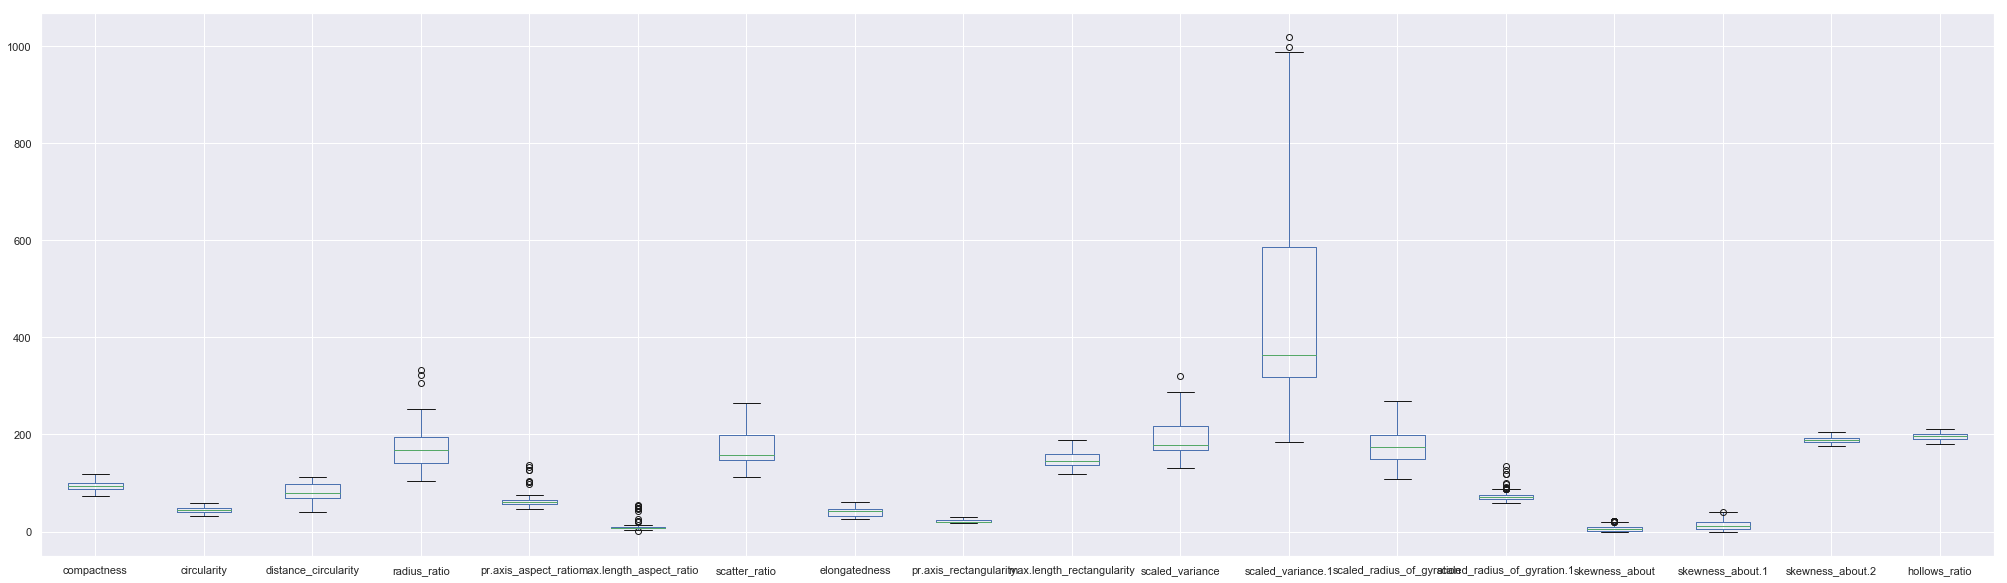

In [744]:
# for col in list(df_org.columns)[:-1]:
#     df_org.boxplot(column=col)
plt.figure(figsize=(35,10))
df_org.boxplot(column=list(df_org.columns)[:-1])

In [745]:
#To get IQR for given column
def iqr(col_name):
    oneandhalf_iqr = (df_summary_fin.loc[col_name]['IQR'])*1.5
    outlier_lb = (df_summary_fin.loc[col_name]['25%'])-oneandhalf_iqr
    outlier_ub = (df_summary_fin.loc[col_name]['75%'])+oneandhalf_iqr
    return oneandhalf_iqr,outlier_lb,outlier_ub

#to get upper & lower outliers count, and its total count for given column
def outliers_cnt(col_name):
    lower_outliers = len(df_org[df_org[col_name]<iqr(col_name)[1]])
    upper_outliers = len(df_org[df_org[col_name]>iqr(col_name)[2]])
    total_outliers = len(df_org[df_org[col_name]<iqr(col_name)[1]])+len(df_org[df_org[col_name]>iqr(col_name)[2]])
    return lower_outliers, upper_outliers, total_outliers

 Outlier details for 'compactness' is {'lower_outliers': 0, 'upper_outliers': 0, 'total_outliers': 0} 


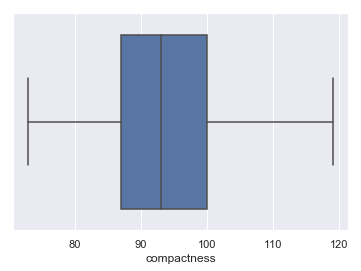

In [746]:
outliers_dict = {"lower_outliers":outliers_cnt('compactness')[0], "upper_outliers":outliers_cnt('compactness')[1],"total_outliers":outliers_cnt('compactness')[2]}
c("Outlier details for 'compactness' is {0}".format(outliers_dict))
sns.boxplot(df_org['compactness']);

C:\Users\Ganesan\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> 'compactness' column data seems to be approximately normally distributed. 


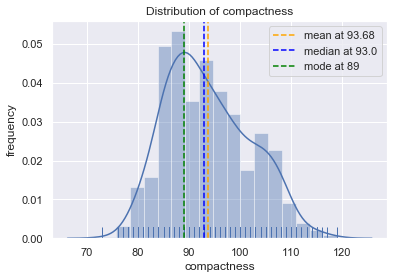

In [747]:
sns.distplot(df_org['compactness'],hist=True, kde=True, rug=True);
plt.xlabel("compactness")
plt.ylabel("frequency")
plt.title(f"Distribution of compactness")
measurements = [round(df_org['compactness'].mean(),2), round(df_org['compactness'].median(),2), round(df_org['compactness'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();
b("")
c("==> 'compactness' column data seems to be approximately normally distributed.")

 Outlier details for 'max.length_aspect_ratio' is {'lower_outliers': 1, 'upper_outliers': 12, 'total_outliers': 13} 


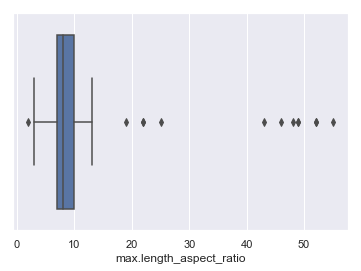

In [748]:
outliers_dict = {"lower_outliers":outliers_cnt('max.length_aspect_ratio')[0], "upper_outliers":outliers_cnt('max.length_aspect_ratio')[1],"total_outliers":outliers_cnt('max.length_aspect_ratio')[2]}
c("Outlier details for 'max.length_aspect_ratio' is {0}".format(outliers_dict))
sns.boxplot(df_org['max.length_aspect_ratio']);

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> 'max.length_aspect_ratio' column data seems to be right skewed. 


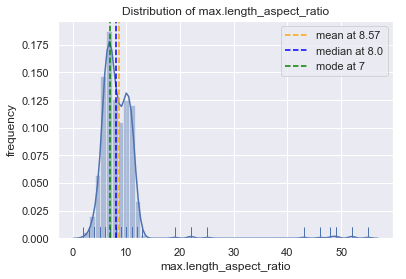

In [749]:
sns.distplot(df_org['max.length_aspect_ratio'],hist=True, kde=True, rug=True);
plt.xlabel("max.length_aspect_ratio")
plt.ylabel("frequency")
plt.title(f"Distribution of max.length_aspect_ratio")
measurements = [round(df_org['max.length_aspect_ratio'].mean(),2), round(df_org['max.length_aspect_ratio'].median(),2), round(df_org['max.length_aspect_ratio'].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();
b("")
c("==> 'max.length_aspect_ratio' column data seems to be right skewed.")

In [750]:
b("")
c("==> Similarly there are other columns that are right/left skewed")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> Similarly there are other columns that are right/left skewed 


In [751]:
#Check if a column contains null values
b("")
for col in list(df_org.columns):
    null_cnt = len(df_org[df_org[col].isnull().values][col]=='True') 
    if null_cnt > 0:
        c("==> There are {0} 'NaN' values present in the column '{1}'".format(null_cnt, col))
    else:
        c("==> There are no 'NaN' values present in the column '{0}'".format(col))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> There are no 'NaN' values present in the column 'compactness' 
 ==> There are 5 'NaN' values present in the column 'circularity' 
 ==> There are 4 'NaN' values present in the column 'distance_circularity' 
 ==> There are 6 'NaN' values present in the column 'radius_ratio' 
 ==> There are 2 'NaN' values present in the column 'pr.axis_aspect_ratio' 
 ==> There are no 'NaN' values present in the column 'max.length_aspect_ratio' 
 ==> There are 1 'NaN' values present in the column 'scatter_ratio' 
 ==> There are 1 'NaN' values present in the column 'elongatedness' 
 ==> There are 3 'NaN' values present in the column 'pr.axis_rectangularity' 
 ==> There are no 'NaN' values present in the column 'max.length_rectangularity' 
 ==>

C:\Users\Ganesan\Anaconda3\lib\site-packages\pandas\core\ops.py:1649: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = method(y)


In [752]:
#Filling missing values using 'interpolate' function
df_org = df_org.interpolate(method ='polynomial', limit_direction ='both', order=3)

In [753]:
df_org.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [754]:
#Check if a column contains null values after filling missing values using interpolating
b("")
for col in list(df_org.columns):
    null_cnt = len(df_org[df_org[col].isnull().values][col]=='True') 
    if null_cnt > 0:
        c("==> There are {0} 'NaN' values present in the column '{1}'".format(null_cnt, col))
    else:
        c("==> There are no 'NaN' values present in the column '{0}'".format(col))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> There are no 'NaN' values present in the column 'compactness' 
 ==> There are no 'NaN' values present in the column 'circularity' 
 ==> There are no 'NaN' values present in the column 'distance_circularity' 
 ==> There are no 'NaN' values present in the column 'radius_ratio' 
 ==> There are no 'NaN' values present in the column 'pr.axis_aspect_ratio' 
 ==> There are no 'NaN' values present in the column 'max.length_aspect_ratio' 
 ==> There are no 'NaN' values present in the column 'scatter_ratio' 
 ==> There are no 'NaN' values present in the column 'elongatedness' 
 ==> There are no 'NaN' values present in the column 'pr.axis_rectangularity' 
 ==> There are no 'NaN' values present in the column 'max.length_rectangularity

### 2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why

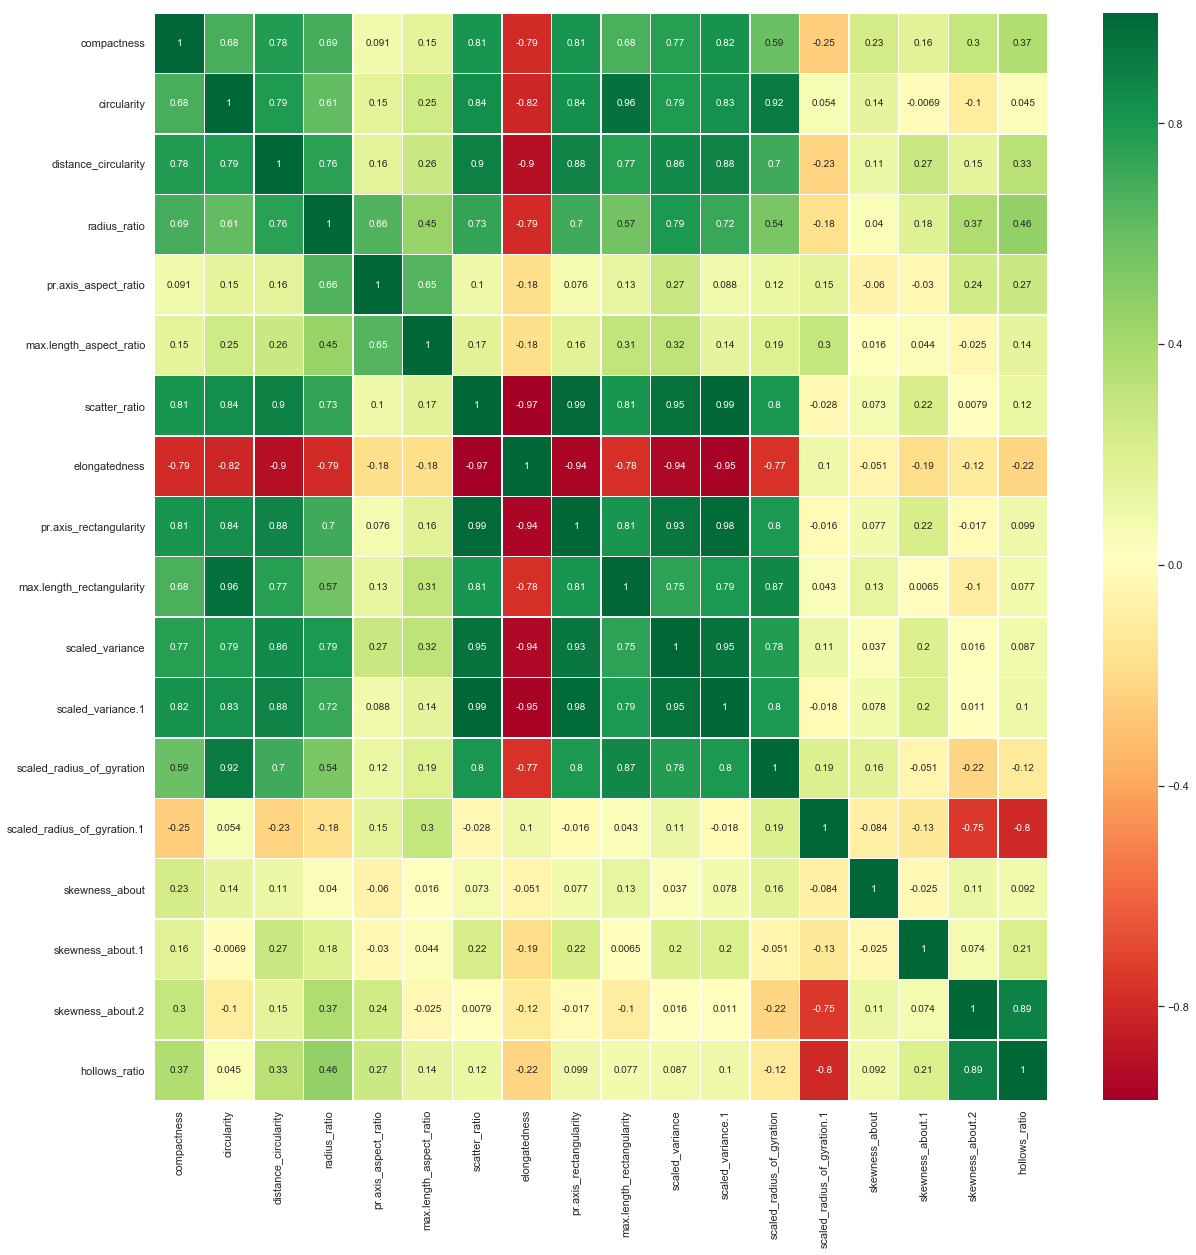

In [666]:
plt.figure(figsize=(20,20))
sns.heatmap(df_org.corr(), annot=True, linewidth=0.5, cmap='RdYlGn');

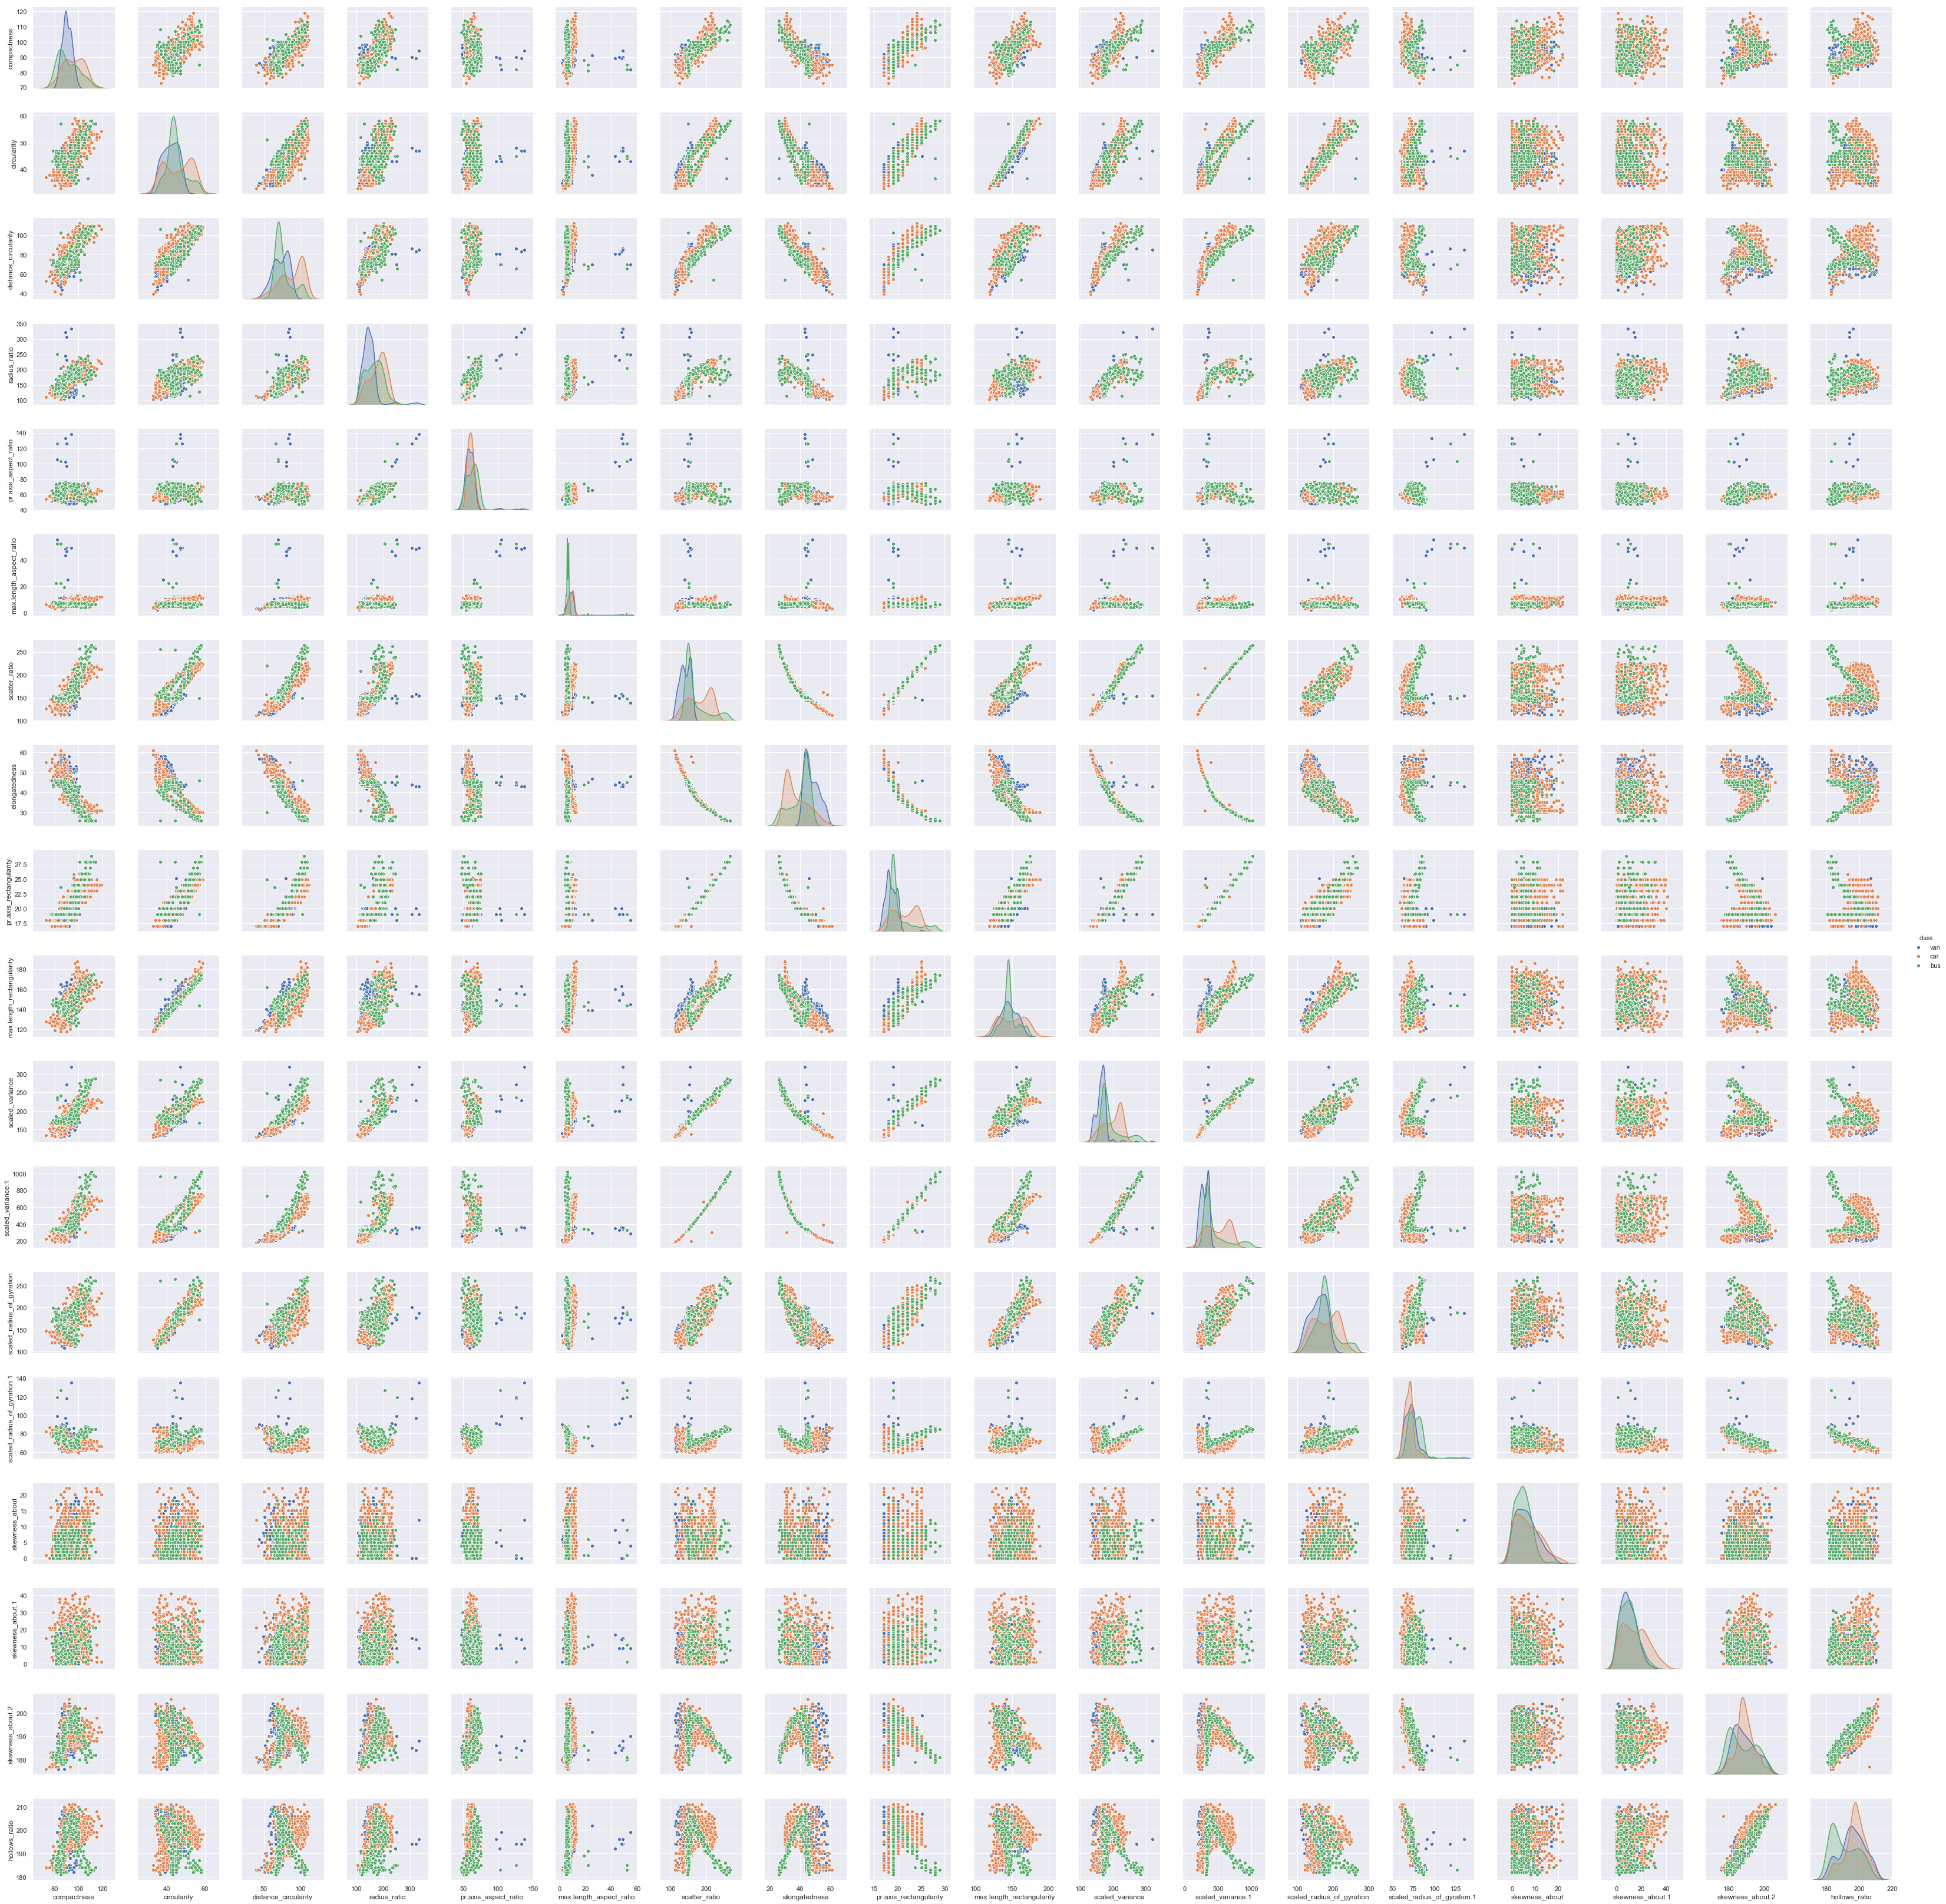

In [232]:
sns.pairplot(df_org, hue='class');

In [699]:
b("")
c("It seems columns 'circularity', 'distance_circularity', 'radius_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration' are highlighly correlated with column 'compactness'. Hence I'm dropping those columns.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 It seems columns 'circularity', 'distance_circularity', 'radius_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration' are highlighly correlated with column 'compactness'. Hence I'm dropping those columns. 


### 3. Split the data into train and test (Suggestion: specify “random state” if you are using train_test_split from Sklearn)

In [784]:
final_results = []
final_results_sc = []
X = df_org.iloc[:, :-1]
y = df_org.iloc[:,-1]
print(X.columns)
len(X), len(y)

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio'],
      dtype='object')


(846, 846)

### 4. Train a Support vector machine using the train set and get the accuracy on the test set

In [755]:
#Split the data into training and test set in the ratio of 70:30 respectively
from sklearn import preprocessing
from sklearn.metrics import classification_report
from sklearn import metrics

random_st = 21
stratify_ind = y
#Without scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# MinMax Normalization
min_max_scaler = preprocessing.MinMaxScaler()
X_minmax = pd.DataFrame(min_max_scaler.fit_transform(X))
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X_minmax, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# Standard Normalization
std_scaler = preprocessing.StandardScaler()
X_std = pd.DataFrame(std_scaler.fit_transform(X))
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# Robust Normalization as there are multiple outliers in the dataset
robust_scaler = preprocessing.RobustScaler()
X_robust = pd.DataFrame(robust_scaler.fit_transform(X))
X_train_robust, X_test_robust, y_train_robust, y_test_robust = train_test_split(X_robust, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

scaling_types = ['No Scaler', 'MinMax Scaler','Standared Normal Scaler', 'Robust Scaler']
X_train_norms, X_test_norms = [[X_train, X_train_minmax, X_train_std, X_train_robust],[X_test, X_test_minmax, X_test_std, X_test_robust]]
y_train_norms, y_test_norms = [[y_train, y_train_minmax, y_train_std, y_train_robust],[y_test, y_test_minmax, y_test_std, y_test_robust]]

SVC - Training f1-score on No Scaler dataset is 0.9696691426742603
SVC - Test f1-score on No Scaler dataset is 0.9448081075766915
No Scaler - SVC - linear - Classification Report:
              precision    recall  f1-score   support

         van       0.97      0.91      0.94        65
         car       0.93      0.97      0.95       129
         bus       0.97      0.93      0.95        60

    accuracy                           0.94       254
   macro avg       0.95      0.94      0.94       254
weighted avg       0.95      0.94      0.94       254

SVC - Training f1-score on MinMax Scaler dataset is 0.8953920686151781
SVC - Test f1-score on MinMax Scaler dataset is 0.8635034203888905
MinMax Scaler - SVC - linear - Classification Report:
              precision    recall  f1-score   support

         van       0.77      0.91      0.83        65
         car       0.95      0.81      0.88       129
         bus       0.82      0.92      0.87        60

    accuracy                 

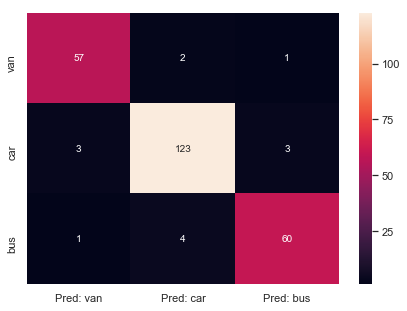

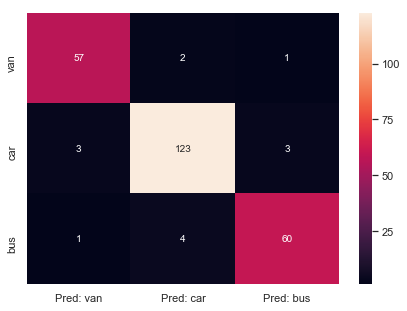

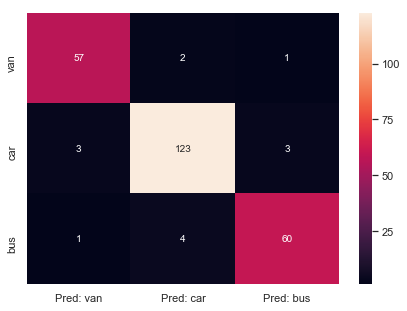

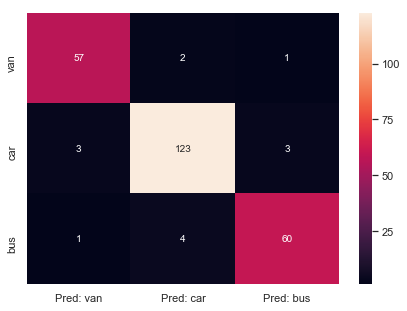

In [756]:
from sklearn.svm import SVC
model_names = []
model_scores = []

# 1. SV - Classifier
solvers = ['linear']
#solvers = ['linear', 'poly', 'rbf', 'sigmoid']
algo_name = "SVC"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
    for solver_name in solvers:
        clf = SVC(C=1.05, tol=1.2, gamma='scale', kernel=solver_name)
        clf.fit(X_train_dataset, y_train_labelset)
        y_train_pred = clf.predict(X_train_dataset)
        y_test_pred = clf.predict(X_test_dataset)
        print("{0} - Training f1-score on {1} dataset is {2}".format(algo_name, scaler_type, metrics.f1_score(y_train_labelset, y_train_pred, average='weighted')))
        print("{0} - Test f1-score on {1} dataset is {2}".format(algo_name, scaler_type, metrics.f1_score(y_test_labelset, y_test_pred, average='weighted')))
        target_values = map(str, df_org['class'].unique().tolist())
        print("{0} - {1} - {3} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_test_pred, target_names=list(target_values)), solver_name))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=['van','car','bus'])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["van","car", "bus"]], columns = [i for i in ["Pred: van","Pred: car", "Pred: bus"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')     
        pred_score = metrics.f1_score(y_test_labelset, y_test_pred, average='weighted')
        model_names.append("{0} - {1} - {2} - {3} - {4}".format(algo_name, solver_name, solver_name, scaler_type, pred_score))
        model_scores.append(pred_score)

In [785]:
final_results.append('SVC - linear - linear - No Scaler - 0.9448081075766915')
final_results_sc.append(94.48081075766915)
model_names

['SVC - linear - linear - No Scaler - 0.6819994778077224']

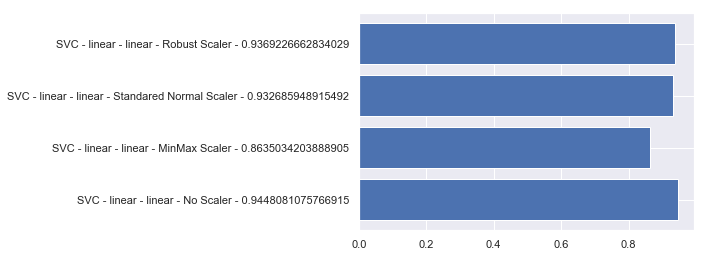

In [758]:
plt.barh(model_names, model_scores)
plt.show()

In [759]:
b("")
c("==> The above results convey that data with NO transformation is performing well comparatively while intacting all the columns as is.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> The above results convey that data with NO transformation is performing well comparatively while intacting all the columns as is. 


### 5. Perform K-fold cross validation and get the cross validation score of the model (optional)

In [760]:
#Checking cross validation score for top performing dataset. ie. No scaled dataset.
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

num_folds = 50
kfold = KFold(n_splits=num_folds, random_state=random_st)
model = SVC(C=1.05, tol=1.1, gamma='scale', kernel=solver_name)
results = cross_val_score(model, X, y, cv=kfold)
print(results)
print("Accuracy: %.3f%% (%.3f%%)" % (results.mean()*100.0, results.std()*100.0))

C:\Users\Ganesan\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:297: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  FutureWarning


[0.88235294 0.94117647 0.94117647 0.88235294 0.88235294 1.
 0.88235294 1.         0.94117647 0.88235294 0.94117647 0.94117647
 1.         0.88235294 1.         1.         0.94117647 0.94117647
 0.94117647 1.         0.88235294 0.94117647 1.         1.
 0.94117647 0.88235294 0.88235294 1.         0.94117647 0.94117647
 0.94117647 1.         0.88235294 1.         0.94117647 0.94117647
 0.88235294 1.         0.88235294 1.         0.88235294 1.
 1.         0.94117647 1.         0.94117647 0.875      1.
 1.         1.        ]
Accuracy: 94.691% (4.764%)


In [761]:
#After dropping less-significant features
#X = df_org.drop(columns=['circularity', 'distance_circularity', 'radius_ratio', 'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration', 'class'])
#X = df_org.drop(columns=['elongatedness', 'pr.axis_rectangularity', 'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration', 'class'])
X = df_org.drop(columns=['elongatedness', 'pr.axis_rectangularity', 'scaled_radius_of_gyration', 'class'])
y = df_org.iloc[:,-1]
print(X.columns)
len(X), len(y)

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'max.length_rectangularity', 'scaled_variance', 'scaled_variance.1',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio'],
      dtype='object')


(846, 846)

In [762]:
#Split the data into training and test set in the ratio of 70:30 respectively
from sklearn import preprocessing
from sklearn.metrics import classification_report
from sklearn import metrics

random_st = 21
stratify_ind = y
#Without scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# MinMax Normalization
min_max_scaler = preprocessing.MinMaxScaler()
X_minmax = pd.DataFrame(min_max_scaler.fit_transform(X))
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X_minmax, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# Standard Normalization
std_scaler = preprocessing.StandardScaler()
X_std = pd.DataFrame(std_scaler.fit_transform(X))
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_std, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

# Robust Normalization as there are multiple outliers in the dataset
robust_scaler = preprocessing.RobustScaler()
X_robust = pd.DataFrame(robust_scaler.fit_transform(X))
X_train_robust, X_test_robust, y_train_robust, y_test_robust = train_test_split(X_robust, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

scaling_types = ['No Scaler', 'MinMax Scaler','Standared Normal Scaler', 'Robust Scaler']
X_train_norms, X_test_norms = [[X_train, X_train_minmax, X_train_std, X_train_robust],[X_test, X_test_minmax, X_test_std, X_test_robust]]
y_train_norms, y_test_norms = [[y_train, y_train_minmax, y_train_std, y_train_robust],[y_test, y_test_minmax, y_test_std, y_test_robust]]

SVC - Training f1-score on No Scaler dataset is 0.9729713069165822
SVC - Test f1-score on No Scaler dataset is 0.9408563189279925
No Scaler - SVC - linear - Classification Report:
              precision    recall  f1-score   support

         van       0.97      0.92      0.94        65
         car       0.92      0.97      0.94       129
         bus       0.96      0.90      0.93        60

    accuracy                           0.94       254
   macro avg       0.95      0.93      0.94       254
weighted avg       0.94      0.94      0.94       254

SVC - Training f1-score on MinMax Scaler dataset is 0.9046027357245823
SVC - Test f1-score on MinMax Scaler dataset is 0.8951529624370724
MinMax Scaler - SVC - linear - Classification Report:
              precision    recall  f1-score   support

         van       0.78      0.94      0.85        65
         car       0.97      0.86      0.91       129
         bus       0.90      0.92      0.91        60

    accuracy                 

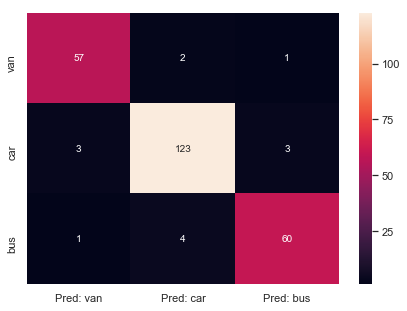

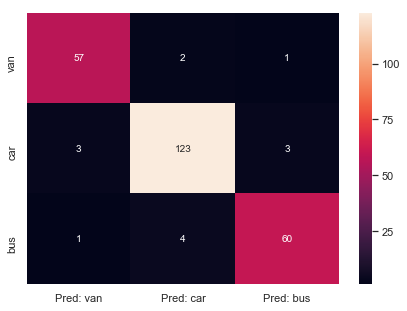

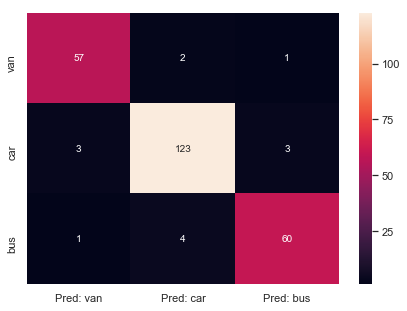

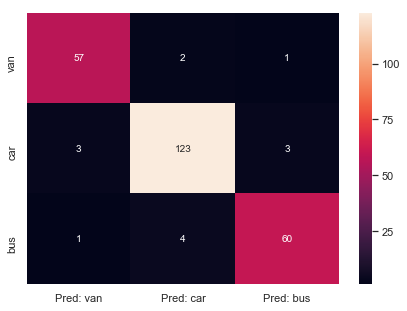

In [763]:
from sklearn.svm import SVC
model_names = []
model_scores = []

# 1. SV - Classifier
solvers = ['linear']
#solvers = ['linear', 'poly', 'rbf', 'sigmoid']
algo_name = "SVC"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
    for solver_name in solvers:
        clf = SVC(C=1.05, tol=1.2, gamma='scale', kernel=solver_name)
        clf.fit(X_train_dataset, y_train_labelset)
        y_train_pred = clf.predict(X_train_dataset)
        y_test_pred = clf.predict(X_test_dataset)
        print("{0} - Training f1-score on {1} dataset is {2}".format(algo_name, scaler_type, metrics.f1_score(y_train_labelset, y_train_pred, average='weighted')))
        print("{0} - Test f1-score on {1} dataset is {2}".format(algo_name, scaler_type, metrics.f1_score(y_test_labelset, y_test_pred, average='weighted')))
        target_values = map(str, df_org['class'].unique().tolist())
        print("{0} - {1} - {3} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_test_pred, target_names=list(target_values)), solver_name))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=['van','car','bus'])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["van","car", "bus"]], columns = [i for i in ["Pred: van","Pred: car", "Pred: bus"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')     
        pred_score = metrics.f1_score(y_test_labelset, y_test_pred, average='weighted')
        model_names.append("{0} - {1} - {2} - {3} - {4}".format(algo_name, solver_name, solver_name, scaler_type, pred_score))
        model_scores.append(pred_score)

In [786]:
model_names
final_results.append('After manual feature elimation - SVC - linear - Standared Normal Scaler - 0.9526591949053931')
final_results_sc.append(95.26591949053931)

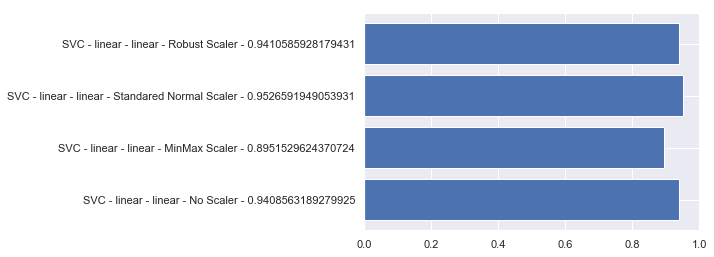

In [765]:
plt.barh(model_names, model_scores)
plt.show()

In [766]:
b("")
c("==> From above results, I observed that data that was transformed with Standard Normalization is performing well comparatively after eliminating few columns such as 'elongatedness', 'pr.axis_rectangularity', 'scaled_radius_of_gyration'\n ==>Also, model performs better after eliminating few less significatly contributing columns that keeping all the columns.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> From above results, I observed that data that was transformed with Standard Normalization is performing well comparatively after eliminating few columns such as 'elongatedness', 'pr.axis_rectangularity', 'scaled_radius_of_gyration'
 ==>Also, model performs better after eliminating few less significatly contributing columns that keeping all the columns. 


### 5. Perform K-fold cross validation and get the cross validation score of the model (optional)

In [767]:
#Checking cross validation score for top performing dataset. ie. std normalized dataset.
num_folds = 50
kfold = KFold(n_splits=num_folds, random_state=random_st)
model = SVC(C=1.05, tol=1.1, gamma='scale', kernel=solver_name)
results = cross_val_score(model, X_std, y, cv=kfold)
print(results)
print("Accuracy: %.3f%% (%.3f%%)" % (results.mean()*100.0, results.std()*100.0))

C:\Users\Ganesan\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:297: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  FutureWarning


[0.88235294 0.82352941 1.         0.82352941 0.94117647 1.
 0.94117647 0.94117647 0.94117647 0.82352941 0.94117647 0.94117647
 1.         0.88235294 1.         1.         0.82352941 0.94117647
 1.         1.         0.70588235 1.         0.94117647 0.94117647
 1.         0.88235294 0.82352941 0.94117647 0.94117647 1.
 0.94117647 1.         0.94117647 1.         0.94117647 0.88235294
 0.94117647 0.94117647 1.         1.         0.88235294 1.
 1.         0.88235294 0.94117647 0.94117647 0.875      0.9375
 1.         0.9375    ]
Accuracy: 93.618% (6.439%)


### 6. Use PCA from Scikit learn, extract Principal Components that capture about 95% of the variance in the data

In [768]:
from scipy.stats import zscore
df_org_zscaled=df_org.iloc[:,:-1].apply(zscore)
df_org_zscaled.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,0.160580,0.513866,0.059246,0.271789,1.310674,0.311542,-0.207613,0.134196,-0.229899,0.758332,-0.403616,-0.343169,0.285986,-0.327276,-0.073621,0.375138,-0.309223,0.183957
1,-0.325470,-0.623808,0.122552,-0.829583,-0.593168,0.094079,-0.599440,0.517737,-0.614510,-0.344578,-0.594573,-0.620650,-0.513266,-0.059935,0.535236,0.152240,0.015341,0.452977
2,1.254193,0.838916,1.515263,1.194561,0.549137,0.311542,1.148711,-1.144273,0.923935,0.689401,1.092220,1.106531,1.392642,0.073735,1.549999,-0.405004,-0.146941,0.049447
3,-0.082445,-0.623808,-0.004059,-0.293780,0.168369,0.094079,-0.750143,0.645584,-0.614510,-0.344578,-0.912836,-0.739571,-1.466220,-1.262968,-0.073621,-0.293555,1.638165,1.529056
4,-1.054545,-0.136234,-0.763720,1.075494,5.245280,9.444962,-0.599440,0.517737,-0.614510,-0.275646,1.665093,-0.648965,0.408948,7.291930,0.535236,-0.182106,-1.445200,-1.699181


In [769]:
covMatrix = np.cov(df_org_zscaled,rowvar=False)

In [1]:
from sklearn.decomposition import PCA
pca = PCA(n_components=9)
pca.fit(df_org_zscaled)

NameError: name 'df_org_zscaled' is not defined

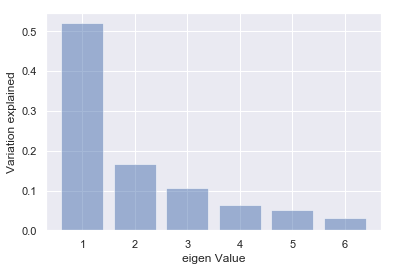

In [771]:
# print(pca.explained_variance_)
# print(pca.components_)
# print(pca.explained_variance_ratio_)
plt.bar(list(range(1,7)),pca.explained_variance_ratio_,alpha=0.5, align='center')
plt.ylabel('Variation explained')
plt.xlabel('eigen Value')
plt.show()

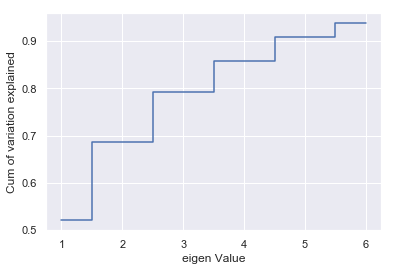

In [772]:
plt.step(list(range(1,7)),np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Cum of variation explained')
plt.xlabel('eigen Value')
plt.show()

In [2]:
,np.cumsum(pca.explained_variance_ratio_

SyntaxError: unexpected EOF while parsing (<ipython-input-2-3a63b589444e>, line 1)

In [773]:
b("")
c("==> The dataset can be reduced as 5 components for the variance of 95%")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> The dataset can be reduced as 5 components for the variance of 95% 


In [774]:
pca5 = PCA(n_components=5)
pca5.fit(df_org_zscaled)
# print(pca5.components_)
# print(pca5.explained_variance_ratio_)
Xpca5 = pca5.transform(df_org_zscaled)
Xpca5.shape

(846, 5)

### 7. Repeat steps 3,4 and 5 but this time, use Principal Components instead of the original data. And the accuracy score should be on the same rows of test data that were used earlier. (hint: set the same random state)

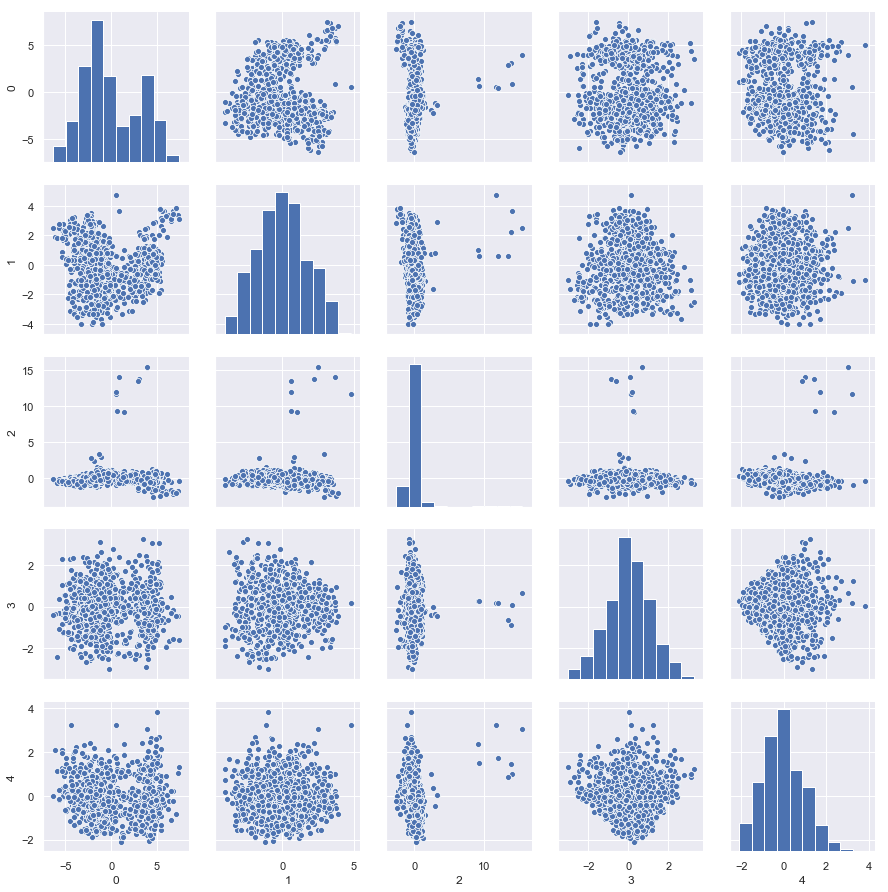

In [775]:
sns.pairplot(pd.DataFrame(Xpca5))

In [776]:
b("")
c("==> Now columns seem to be independent without having much correlation")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> Now columns seem to be independent without having much correlation 


In [777]:
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(Xpca5, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)
X_train_norms, X_test_norms = [[X_train_std],[X_test_std]]
y_train_norms, y_test_norms = [[y_train_std],[y_test_std]]

SVC - Training f1-score on No Scaler dataset is 0.6733252443014696
SVC - Test f1-score on No Scaler dataset is 0.6819994778077224
No Scaler - SVC - linear - Classification Report:
              precision    recall  f1-score   support

         van       0.54      0.69      0.61        65
         car       0.76      0.74      0.75       129
         bus       0.71      0.53      0.61        60

    accuracy                           0.68       254
   macro avg       0.67      0.66      0.66       254
weighted avg       0.69      0.68      0.68       254



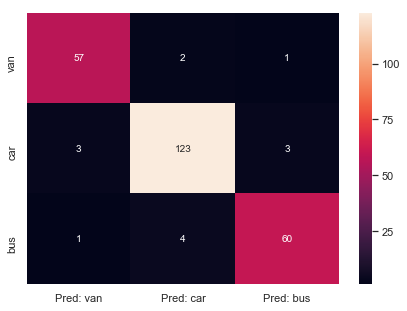

In [778]:
from sklearn.svm import SVC
model_names = []
model_scores = []

# 1. SV - Classifier
solvers = ['linear']
#solvers = ['linear', 'poly', 'rbf', 'sigmoid']
algo_name = "SVC"
for scaler_type, X_train_dataset, y_train_labelset, X_test_dataset, y_test_labelset in zip(scaling_types, X_train_norms, y_train_norms, X_test_norms, y_test_norms):
    for solver_name in solvers:
        clf = SVC(C=1.05, tol=1.2, gamma='scale', kernel=solver_name)
        clf.fit(X_train_dataset, y_train_labelset)
        y_train_pred = clf.predict(X_train_dataset)
        y_test_pred = clf.predict(X_test_dataset)
        print("{0} - Training f1-score on {1} dataset is {2}".format(algo_name, scaler_type, metrics.f1_score(y_train_labelset, y_train_pred, average='weighted')))
        print("{0} - Test f1-score on {1} dataset is {2}".format(algo_name, scaler_type, metrics.f1_score(y_test_labelset, y_test_pred, average='weighted')))
        target_values = map(str, df_org['class'].unique().tolist())
        print("{0} - {1} - {3} - Classification Report:\n{2}".format(scaler_type, algo_name, classification_report(y_test_labelset, y_test_pred, target_names=list(target_values)), solver_name))
        conf_mat = metrics.confusion_matrix(y_test_labelset, y_pred, labels=['van','car','bus'])
        df_conf_mat = pd.DataFrame(conf_mat, index = [i for i in ["van","car", "bus"]], columns = [i for i in ["Pred: van","Pred: car", "Pred: bus"]])
        plt.figure(figsize = (7,5))
        sns.heatmap(df_conf_mat, annot=True, fmt='g')     
        pred_score = metrics.f1_score(y_test_labelset, y_test_pred, average='weighted')
        model_names.append("{0} - {1} - {2} - {3} - {4}".format(algo_name, solver_name, solver_name, scaler_type, pred_score))
        model_scores.append(pred_score)

In [787]:
final_results.append('After PCA feature elimnation - SVC - Z-Scaler dataset is 0.6819994778077224')
final_results_sc.append(68.19994778077224)

In [780]:
#Checking cross validation score for top performing dataset. ie. std normalized dataset.
num_folds = 50
kfold = KFold(n_splits=num_folds, random_state=random_st)
model = SVC(C=1.05, tol=1.1, gamma='scale', kernel=solver_name)
results = cross_val_score(model, Xpca5, y, cv=kfold)
print(results)
print("Accuracy: %.3f%% (%.3f%%)" % (results.mean()*100.0, results.std()*100.0))

C:\Users\Ganesan\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:297: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  FutureWarning


[0.52941176 0.58823529 0.52941176 0.52941176 0.64705882 0.64705882
 0.64705882 0.52941176 0.70588235 0.76470588 0.52941176 0.82352941
 0.52941176 0.70588235 0.58823529 0.76470588 0.52941176 0.52941176
 0.76470588 0.76470588 0.70588235 0.70588235 0.58823529 0.76470588
 0.70588235 0.82352941 0.58823529 0.70588235 0.76470588 0.76470588
 0.82352941 0.64705882 0.76470588 0.82352941 0.76470588 0.64705882
 0.70588235 0.70588235 0.76470588 0.52941176 0.29411765 0.88235294
 0.82352941 0.52941176 0.70588235 0.76470588 0.6875     0.5625
 0.75       0.5       ]
Accuracy: 66.882% (11.735%)


### 8. Compare the accuracy scores and cross validation scores of Support vector machines – one trained using raw data and the other using Principal Components, and mention your findings

In [781]:
final_results

['SVC - linear - linear - No Scaler - 0.9448081075766915',
 'After manual feature elimation - SVC - linear - Standared Normal Scaler - 0.9526591949053931',
 'After PCA feature elimnation - SVC - Z-Scaler dataset is 0.6819994778077224']

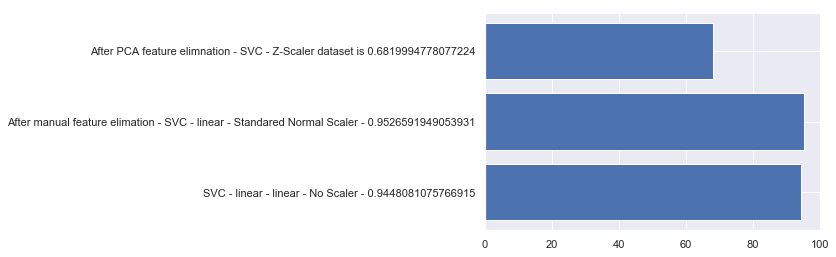

In [788]:
plt.barh(final_results, final_results_sc)
plt.show()

In [782]:
b("")
c("==> From above results, ''After manual feature elimation - SVC - linear - Standared Normal Scaler' performs well than any other models after perform standardization and feature selection")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> From above results, ''After manual feature elimation - SVC - linear - Standared Normal Scaler' performs well than any other models after perform standardization and feature selection 
